In [7]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd

In [2]:
gainmat='../output/wb_simulations/SPMgainmatrix_pcspm_converted_autoreject-sub-001-ses-01-motor-epo_1.mat'
with h5py.File(gainmat,'r') as file:
    lf_mat=file['G'][()]
lf_mat.shape

(320430, 275)

In [3]:
def compute_edge_separability(G, n_layers, use_abs=True, eps=1e-12):
    """
    Compute layer-wise lead-field separability for each cortical vertex.

    Parameters
    ----------
    G : array, shape (n_sources, n_sensors)
        Gain matrix with sources ordered by concatenated layers:
        [layer 1 vertices, layer 2 vertices, ..., layer n vertices],
        from pial/superficial to white/deep.

    n_layers : int
        Number of cortical depth layers.

    use_abs : bool
        If True, use 1 - abs(cosine similarity), making the metric
        insensitive to sign flips in lead fields.

    eps : float
        Small constant to avoid division by zero.

    Returns
    -------
    E_verts : array, shape (n_vertices_per_layer, n_layers)
        Mean cosine dissimilarity of each layer's lead field to all
        other layers, computed separately for each cortical vertex.

        Higher values indicate that a layer is more separable from
        the remaining cortical depths at the sensor level.
    """

    G = np.asarray(G, dtype=float)

    if G.ndim != 2:
        raise ValueError("G must have shape (n_sources, n_sensors).")

    n_sources, _ = G.shape

    if n_sources % n_layers != 0:
        raise ValueError("n_sources must be divisible by n_layers.")

    n_vertices = n_sources // n_layers

    # Shape: layers × vertices × sensors
    G_lvs = G.reshape(n_layers, n_vertices, -1)

    # Normalize lead fields
    norms = np.linalg.norm(G_lvs, axis=2, keepdims=True)
    G_norm = G_lvs / np.maximum(norms, eps)

    E_verts = np.empty((n_vertices, n_layers))

    for v in range(n_vertices):

        # Cosine similarity across layers
        sim = G_norm[:, v, :] @ G_norm[:, v, :].T

        if use_abs:
            sim = np.abs(sim)

        # Cosine dissimilarity
        dist = 1.0 - sim

        # Ignore self-comparisons
        np.fill_diagonal(dist, np.nan)

        # Mean dissimilarity of each layer to all others
        E = np.nanmean(dist, axis=1)

        E_verts[v, :] = E

    return E_verts

In [4]:
E = compute_edge_separability(lf_mat, n_layers=11)

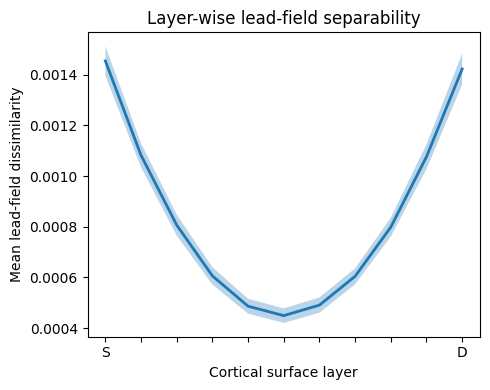

In [5]:
mean_E = np.mean(E, axis=0)
sem_E = np.std(E, axis=0) / np.sqrt(E.shape[0])

layers = np.arange(1, len(mean_E) + 1)

plt.figure(figsize=(5, 4))

plt.plot(layers, mean_E, linewidth=2)
plt.fill_between(
    layers,
    mean_E - sem_E,
    mean_E + sem_E,
    alpha=0.3
)
plt.xticks(
    [1, len(mean_E)],
    ['S', 'D']
)

plt.xticks(layers)
plt.xlabel('Cortical surface layer')
plt.ylabel('Mean lead-field dissimilarity')
plt.title('Layer-wise lead-field separability')

plt.tight_layout()
plt.savefig('./figure_S2_lead_field_separability.pdf')

In [8]:
data={
    'layer': [],
    'm_sep': [],
    'se_sep': []
}
for l_idx,l in enumerate(layers):
    data['layer'].append(l)
    data['m_sep'].append(mean_E[l_idx])
    data['se_sep'].append(sem_E[l_idx])
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_S02.csv', index=False)